### SIMPLE LINEAR REGRESSION

In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
%matplotlib inline

In [3]:
df = pd.read_csv('SOCR-HeightWeight.csv')
df.head()

,Index,Height(Inches),Weight(Pounds)
0,1,65.78331,112.9925
1,2,71.51521,136.4873
2,3,69.39874,153.0269
3,4,68.21660,142.3354
4,5,67.78781,144.2971


Text(0, 0.5, 'Weight')

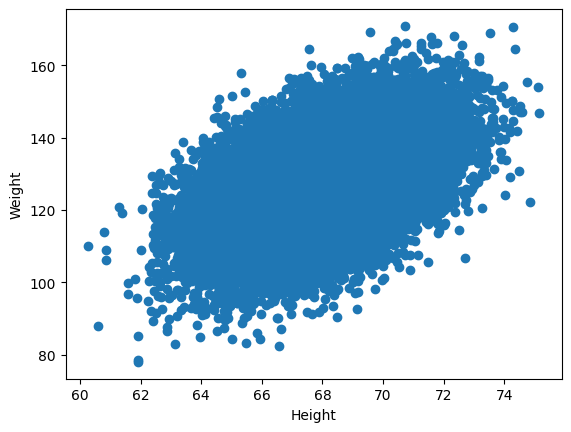

In [22]:
plt.scatter(df['Weight(Pounds)'],df['Height(Inches)'])
plt.xlabel("Weight")
plt.ylabel("Height")

### STEPS INVOLVED 
1. divide the features in the dataset based on independent and dependent features
2. train test split of the dataset inorder to train model using training data and test it using the sample data 
3. Standardizing the dataset
4. training the model using linear regression

In [11]:
X = df[['Weight(Pounds)']] #independent feature
y = df['Height(Inches)']  #dependent feature

In [12]:
X

,Weight(Pounds)
0,112.9925
1,136.4873
2,153.0269
3,142.3354
4,144.2971
...,...
24995,118.0312
24996,120.1932
24997,118.2655
24998,132.2682


In [13]:
y

0        65.78331
1        71.51521
2        69.39874
3        68.21660
4        67.78781
           ...   
24995    69.50215
24996    64.54826
24997    64.69855
24998    67.52918
24999    68.87761
Name: Height(Inches), Length: 25000, dtype: float64

In [14]:
#train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=42)


In [15]:
X.shape

(25000, 1)

In [16]:
X_train.shape, X_test.shape

((20000, 1), (5000, 1))

In [18]:
# Standardizing the data (mainly independent features)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

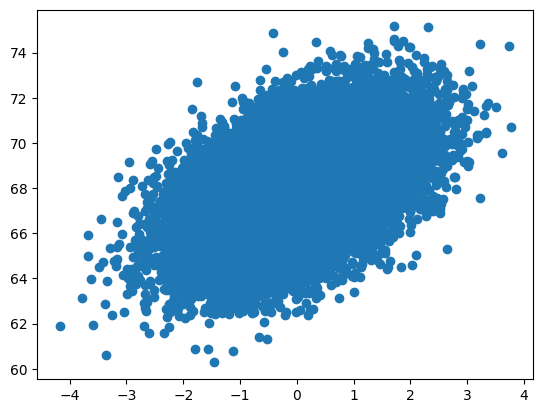

In [19]:
plt.scatter(X_train, y_train)

In [20]:
# training the simple linear regression model 
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [23]:
print("the slope or coefficient of weight is ",regressor.coef_)
print("Intercept: ",regressor.intercept_)

the slope or coefficient of weight is  [0.95022131]
Intercept:  67.99034523350001


In [29]:
y_pred_train = regressor.predict(X_train)

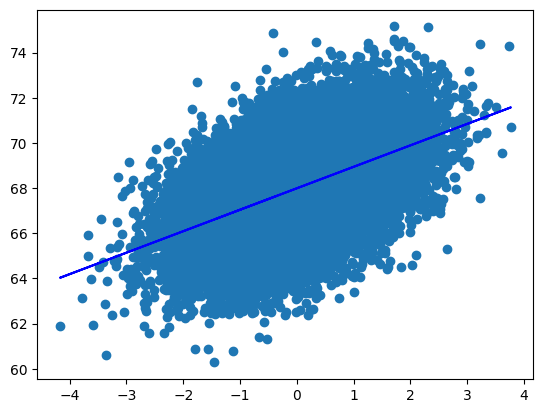

In [28]:
plt.scatter(X_train,y_train)
plt.plot(X_train, regressor.predict(X_train),color='b')

### prediction of train data
1. predicted height output = intercept + coef(Weights)
2. y_pred_train = 67.99034523350001 + 0.95022131(X_train)

### prediction of test data 
same 

In [30]:
y_pred_test = regressor.predict(X_test)


In [31]:
y_pred_test,y_test

(array([68.57909757, 66.75591741, 68.7180974 , ..., 69.14277554,
        68.19031301, 68.61726207], shape=(5000,)),
 6868     68.42447
 24016    67.89663
 9668     67.65922
 13640    69.01299
 14018    69.01055
            ...   
 8670     68.93627
 11839    67.28489
 4013     68.57098
 21147    67.09562
 695      70.56979
 Name: Height(Inches), Length: 5000, dtype: float64)

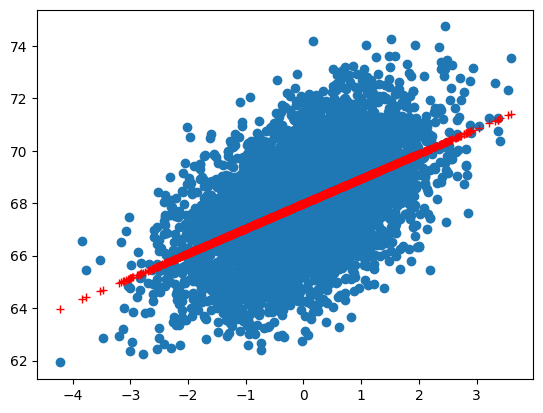

In [33]:
plt.scatter(X_test, y_test)
plt.plot(X_test,y_pred_test,'r+')

 performance matrix.

 MSE, MAe, RMSE.

squared and adjusted r squared.

In [34]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
mse = mean_squared_error(y_test,y_pred_test)
mae = mean_absolute_error(y_test,y_pred_test)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

2.724962846065037
1.316304056930067
1.6507461482811452


In [36]:
from sklearn.metrics import r2_score
score = r2_score(y_test,y_pred_test)
print(score)

0.26055631630450127


In [37]:
1-(1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.2604083683885958

In [41]:
scaled_weight = scaler.transform([[120]])
scaled_weight

d:\machine learning\python\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[-0.60848736]])

In [43]:
print("height prediction for weight 120 pounds is: ")
print(regressor.predict([scaled_weight[0]]))

height prediction for weight 120 pounds is: 
[67.41214758]


### assumptions
1. plot a scatter plot for prediction
2. residuals

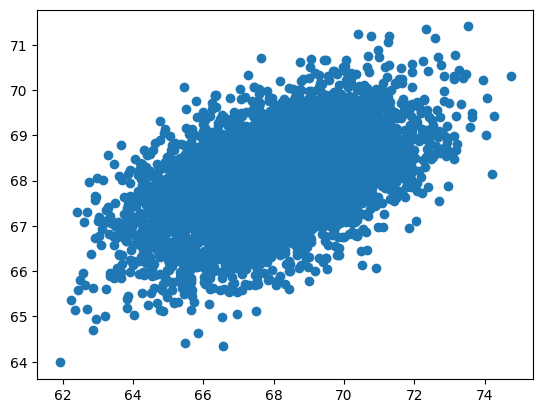

In [44]:
plt.scatter(y_test,y_pred_test)

In [45]:
residuals = y_test-y_pred_test
residuals

6868    -0.154628
24016    1.140713
9668    -1.058877
13640    1.079658
14018    3.217371
           ...   
8670     0.046057
11839    1.080896
4013    -0.571796
21147   -1.094693
695      1.952528
Name: Height(Inches), Length: 5000, dtype: float64

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_19080\3762910054.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residuals,kde=True)


<Axes: xlabel='Height(Inches)', ylabel='Density'>

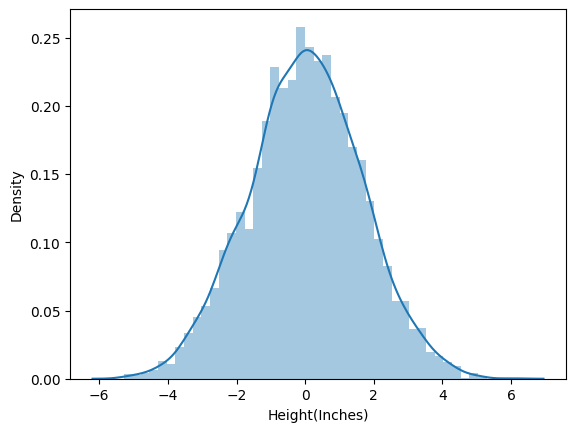

In [46]:
sns.distplot(residuals,kde=True)

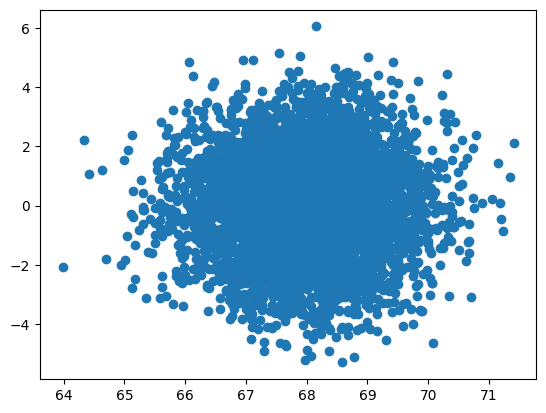

In [47]:
plt.scatter(y_pred_test,residuals)